In [ ]:
import torch
import torch.nn as nn
import torchinfo
from model.mini_cnn import MiniCNN
from result.repondeur import prediction_to_csv
import torchvision
import numpy as np
import csv
from tqdm import tqdm
from model.loader import load_dataset, load_test_loader
import os
from torchmetrics.classification import F1Score
from utils.compute_weights import compute_class_weights

ModuleNotFoundError: No module named 'torch'

In [3]:
# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("⚠ Using CPU - training will be slow!")

✓ Using Apple Silicon GPU (MPS)


In [ ]:
def train_crossEntropyLoss(train_set, model, epochs):
    """
    Entraine un model à partir d'un train_set donné. Retourne les metrics de l'entrainement
    """
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

    # Initialize metric storage
    accuracies = np.zeros(epochs)
    losses = np.zeros(epochs)
    f1_scores = np.zeros(epochs) # Added to track per epoch
    
    # Assuming 50 classes as per your snippet
    f1_metric = F1Score(task="multiclass", num_classes=50, average='macro').to(device)

    for epoch in range(epochs):
        f1_metric.reset()
        total_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_set, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            logits = model(images)
            loss = criterion(logits, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics calculation
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            
            # Update F1 state with current batch
            f1_metric.update(preds, labels)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Display running metrics
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{correct/total*100:.2f}%",
                "f1": f"{f1_metric.compute():.4f}"
            })

        # Store epoch results
        accuracies[epoch] = correct / total
        losses[epoch] = total_loss / len(train_set)
        f1_scores[epoch] = f1_metric.compute().item() # Store final epoch F1

        scheduler.step()
        
    return accuracies, losses, f1_scores

In [ ]:
weights = compute_class_weights('data/treated_train')
weights = weights.to(device)

def train_weightLoss(train_set, model, epochs, weights=weights):
    """
    Entraine un model à partir d'un train_set donné. Retourne les metrics de l'entrainement
    """

    # Parameters
    model.train()

    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=200
    )


    accuracies = np.zeros(epochs)
    losses = np.zeros(epochs)
    f1_metric = F1Score(task="multiclass", num_classes=50, average='macro').to(device)

    for epoch in range(epochs):
        f1_metric.reset()
        total_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(
            train_set,
            desc=f"Model training | Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            #prediction
            logits = model(images)
            loss = criterion(logits, labels)

            #propagation du gradient
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calcul des metriques
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({
                "batch_loss": f"{loss.item():.4f}",
                "accuracy": f"{correct/total*100:.2f}%",
                "f1": f"{f1_metric(preds, labels):.4f}"
            })
        accuracies[epoch] = correct/total
        losses[epoch] = total_loss

        scheduler.step()
    return accuracies, losses

In [1]:
pwd()

'/home/hugor/Documents/etudes/SDD/FSD313/MielPops'

In [ ]:
###---IGNORE---###

import os

def count_files_in_subs(path='data/train'):
    # Get all items and filter for directories
    subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    
    # Sort them alphabetically (case-insensitive)
    subdirs.sort(key=str.lower)
    
    counts = {}
    for folder in subdirs:
        sub_path = os.path.join(path, folder)
        # Count only files in this subdirectory
        file_count = len([f for f in os.listdir(sub_path) if os.path.isfile(os.path.join(sub_path, f))])
        counts[folder] = file_count
        
    return counts

# Execution
# results = count_files_in_subs()
# for folder, count in results.items():
#     print(f"{folder}: {count}")

def compute_class_weights(path='data/train'):
    counts = count_files_in_subs(path)
    total_files = sum(counts.values())
    weights = {folder: total_files / (len(counts) * count) for folder, count in counts.items()}
    return weights


weights = compute_class_weights(path='data/train')
print("\nClass Weights:")
for folder, weight in weights.items():
    print(f"{folder}: {weight:.2f}")

weights = torch.tensor(list(weights.values()), dtype=torch.float32).to(device)



Class Weights:
Andrena aerinifrons: 11.43
Andrena afrensis: 32.00
Andrena aliciae: 1.50
Andrena angustitarsata: 5.93
Andrena banksi: 4.44
Andrena barbareae: 4.44
Andrena barbilabris: 0.28
Andrena bicolor: 0.32
Andrena carantonica: 0.64
Andrena chengtehensis: 20.00
Andrena cineraria: 0.23
Andrena clarkella: 0.34
Andrena convallaria: 4.85
Andrena costillensis: 26.66
Andrena crawfordi: 14.54
Andrena denticulata: 0.22
Andrena dilleri: 26.66
Andrena discors: 16.00
Andrena dorsata: 0.50
Andrena flavipes: 0.41
Andrena florivaga: 4.57
Andrena fortipunctata: 39.99
Andrena fulva: 0.25
Andrena fulvata: 26.66
Andrena haemorrhoa: 0.37
Andrena hattorfiana: 0.45
Andrena hesperia: 8.42
Andrena irana: 26.66
Andrena leucophaea: 20.00
Andrena limbata: 3.81
Andrena lineolata: 4.21
Andrena mediovittata: 5.33
Andrena melanochroa: 22.85
Andrena mendica: 26.66
Andrena nigroaenea: 0.56
Andrena nitida: 0.26
Andrena orbitalis: 7.27
Andrena perimelas: 2.22
Andrena perplexa: 6.96
Andrena pinguis: 26.66
Andrena pl

In [5]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from utils.CustomDataset import CustomDataset
from utils.CustomSkibidiDataset import CustomSkibidiDataset

from torchvision.transforms import v2

In [6]:
# 1. Define Image Transforms
# HUUUUGOOOOOOOO
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     torchvision.transforms.functional.to_dtype(float16, scale=True),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

transform = v2.Compose([
    #v2.ToImage(),                  # Convert to Tensor (if it's PIL)
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True), # Scales to float16 [0, 1] # TODO
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# 2. Instantiate your Dataset
"""train_dataset = CustomDataset(
    img_dir='data/',
    annotations_file='data/train.csv',
    transform=transform, 
    target_transform=None # ???
)"""

skibidi_dataset = CustomSkibidiDataset(
    img_dir='data/treated_train/',
    csv_mapper='data/treated_train.csv',
    transform=transform, 
    target_transform=None # ???
)

train_size = int(0.8 * len(skibidi_dataset))
test_size = len(skibidi_dataset) - train_size

train_dataset, validation_dataset = random_split(skibidi_dataset, [train_size, test_size])

Found folders ['Andrena hattorfiana', 'Andrena fulvata', 'Andrena haemorrhoa', 'Andrena leucophaea', 'Andrena banksi', 'Andrena dorsata', 'Andrena florivaga', 'Andrena barbareae', 'Andrena convallaria', 'Andrena fulva', 'Andrena nitida', 'Andrena lineolata', 'Andrena bicolor', 'Andrena fortipunctata', 'Andrena villipes', 'Andrena denticulata', 'Andrena angustitarsata', 'Andrena mendica', 'Andrena aerinifrons', 'Andrena costillensis', 'Andrena chengtehensis', 'Andrena wilkella', 'Andrena irana', 'Andrena discors', 'Andrena barbilabris', 'Andrena plana', 'Andrena prodigiosa', 'Andrena orbitalis', 'Andrena nigroaenea', 'Andrena ventralis', 'Andrena rudbeckiae', 'Andrena vaga', 'Andrena flavipes', 'Andrena pinguis', 'Andrena perplexa', 'Andrena aliciae', 'Andrena mediovittata', 'Andrena melanochroa', 'Andrena cineraria', 'Andrena vulpecula', 'Andrena rufula', 'Andrena afrensis', 'Andrena carantonica', 'Andrena hesperia', 'Andrena vicinoides', 'Andrena limbata', 'Andrena dilleri', 'Andrena 

In [7]:
#set up training
epochs = 5
model = MiniCNN()
model.to(device)

train_set = DataLoader(
    dataset=train_dataset,
    batch_size=32,      # Number of images per batch
    shuffle=True,       # Shuffle every epoch to prevent overfitting
    num_workers=4,      # Number of CPU cores for data loading
    pin_memory=True     # Speeds up transfer to GPU
)

validation_test = DataLoader(
    dataset=validation_dataset,
    batch_size=32,      # Number of images per batch
    shuffle=True,       # Shuffle every epoch to prevent overfitting
    num_workers=4,      # Number of CPU cores for data loading
    pin_memory=True     # Speeds up transfer to GPU
)

Model training | Epoch 1/5:   0%|          | 0/656 [00:00<?, ?it/s]/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Model training | Epoch 1/5: 100%|██████████| 656/656 [03:24<00:00,  3.21it/s, batch_loss=3.2997, accuracy=9.96%]
Model training | Epoch 2/5: 100%|██████████| 656/656 [03:36<00:00,  3.03it/s, batch_loss=2.8967, accuracy=19.50%]
Model training | Epoch 3/5: 100%|██████████| 656/656 [04:17<00:00,  2.55it/s, batch_loss=3.2141, accuracy=27.56%]  
Model training | Epoch 4/5: 100%|██████████| 656/656 [03:40<00:00,  2.97it/s, batch_loss=1.6622, accuracy=34.27%]
Model training | Epoch 5/5: 100%|██████████| 656/656 [03:32<00:00,  3.08it/s, batch_loss=1.6849, accuracy=40.92%]


In [ ]:
#training
training_curves, training_curves = train_crossEntropyLoss(train_set,model, epochs)

In [ ]:
torch.save(model.state_dict(), f"model/trained_model/MiniCNN_{epochs}_epochs.pth")

In [14]:
import csv

In [17]:
def prediction_to_csv(validation_dataset,model) :
    """
    Charge un dataset et retourne le csv des predictions associé.
    """

    model = model.to(device)
    model.eval()

    id = 0

    # enregistre les predictions
    predictions_array = []

    with torch.no_grad() :
        
        pbar = tqdm(
            validation_dataset,
            desc="Inference"
        )

        for images, labels in pbar :

            images = images.to(device) # a modifier en fonction du test_set
            img_logits = model(images)


            predictions = img_logits.argmax(dim=1)
            predictions = predictions.cpu().numpy()

            for pred, label in zip(predictions, labels):
                id += 1
                predictions_array.append({
                    "id": id,
                    "pred": int(pred),
                    "true": int(label)
                })

        output_path = f"prediction.csv"

        # Sauvegarde CSV
        with open(output_path, "w", newline='', encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames = ["id", "pred", "true"])
            writer.writeheader()
            writer.writerows(predictions_array)
        print(f"Les predictions ont été sauvegardees dans {output_path}.")

In [18]:
prediction_to_csv(validation_test, model)

Inference:   0%|          | 0/164 [00:00<?, ?it/s]/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Inference: 100%|██████████| 164/164 [00:39<00:00,  4.17it/s]

Les predictions ont été sauvegardees dans prediction.csv.


In [28]:
import pandas as pd
from eval.Analyser import Analyser

In [34]:
data = pd.read_csv("prediction.csv")

analyser = Analyser(data)
report = analyser.generate_report()
print(report)

{'f1_score_avg': 0.28708540208615774, 'f1_score_per_class': array([0.30769231, 0.0483871 , 0.72340426, 0.32542373, 0.02352941,
       0.05405405, 0.64761905, 0.61654135, 0.28865979, 0.14285714,
       0.25930101, 0.        , 0.        , 0.22222222, 0.32490975,
       0.53623188, 0.16748768, 0.2893617 , 0.06802721, 0.51282051,
       0.4375    , 0.07246377, 0.52475248, 0.17748344, 0.29559748,
       0.19444444, 0.        , 0.61702128, 0.27906977, 0.58823529,
       0.05333333, 0.15873016, 0.0754717 , 0.28169014, 0.10891089,
       0.6342711 , 0.29565217, 0.29239766, 0.26515152, 0.08484848,
       0.28888889, 0.30120482, 0.53676471, 0.04968944, 0.22754491,
       0.31683168, 0.2195122 ]), 'best_f1': np.int64(2)}


In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_f1_report(report_dict):
    """
    Plot le F1-score par classe + la moyenne.
    """

    f1_scores = report_dict["f1_score_per_class"]
    f1_avg = report_dict["f1_score_avg"]
    best_class = int(report_dict["best_f1"])

    plt.figure(figsize=(12, 5))

    # Barres
    plt.bar(range(len(f1_scores)), f1_scores)

    # Ligne moyenne
    plt.axhline(y=f1_avg)

    # Highlight meilleure classe
    plt.scatter(best_class, f1_scores[best_class])

    plt.title("F1-score par classe")
    plt.xlabel("Classe")
    plt.ylabel("F1-score")
    plt.xticks(range(len(f1_scores)))
    plt.ylim(0, 1)

    plt.show()

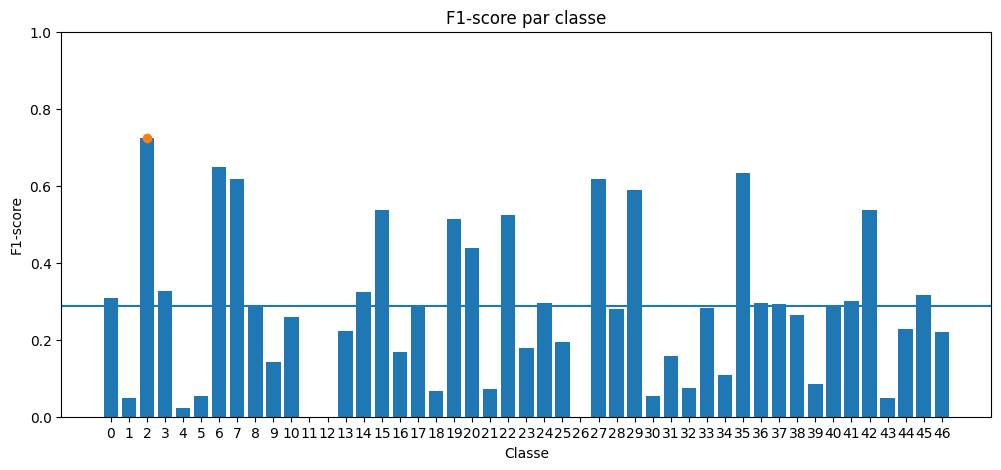

In [36]:
plot_f1_report(report)